# Тестовое задание: младший продуктовый аналитик РБК
## Разбор логов pro.rbc.ru за неделю с 23 по 29 мая 2022

Ниже — весь ход решения: загрузка данных, расчёты и графики по каждому из четырёх вопросов задания. Выводы и комментарии по цифрам — в markdown-ячейках между кодом, финальный (более читаемый) вариант с той же логикой собран отдельным docx-отчётом.

Исходные данные — 7 csv-файлов, по одному на каждый день недели, 23-29 мая 2022, кодировка UTF-8, разделитель `,`. Файлы называются по дате: `2022-05-23.csv` ... `2022-05-29.csv`.


## 0. Импорт и настройка

Файлы суммарно тянут почти на 1,4 ГБ и 3,8 млн строк,так что будим читать по частям.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
from collections import defaultdict

DATA_DIR = '/mnt/user-data/uploads'
USECOLS = ['timestamp', 'splituid', 'uuid', 'auth']
CHUNKSIZE = 300_000

# 23.05.2022 - понедельник, дальше по порядку
FILES = {
    '2022-05-23': ('Пн', 0, False),
    '2022-05-24': ('Вт', 1, False),
    '2022-05-25': ('Ср', 2, False),
    '2022-05-26': ('Чт', 3, False),
    '2022-05-27': ('Пт', 4, False),
    '2022-05-28': ('Сб', 5, True),
    '2022-05-29': ('Вс', 6, True),
}


## 1. Что вообще в данных

Сначала просто посмотрел первые строки, чтобы понять формат полей — особенно timestamp, от него зависело, как быстро можно будет вытаскивать час и дату.

In [2]:
df_sample = pd.read_csv(f'{DATA_DIR}/2022-05-23.csv', nrows=5)
df_sample[['timestamp','splituid','uuid','auth','mobile','status']]

,timestamp,splituid,uuid,auth,mobile,status
0,2022-05-23T18:03:02.552+03:00,UET9A2IUgkdX8KQDA4DSAg==,NaN,0,1,200
1,2022-05-23T18:03:00.744+03:00,UET9A2IUgkdX8KQDA4DSAg==,NaN,0,1,200
2,2022-05-23T14:01:50.175+03:00,UET9A2Et58cp/rnwA0wyAg==,NaN,0,0,200
3,2022-05-23T15:55:47.637+03:00,UET9A2HmanROl3p0AxwgAg==,NaN,0,0,200
4,2022-05-23T14:11:23.743+03:00,UET9A1/8GiTBO5bBAxXKAg==,cde30582-68c4-49f1-87c2-dbde33df8d89,1,0,200


Формат timestamp фиксированный (`YYYY-MM-DDTHH:MM:SS.sss+03:00`), так что час можно вытащить обычным срезом строки — это на порядок быстрее, чем гонять всё через `pd.to_datetime` на 3,8 миллионах строк.

## 2. Основной проход по файлам

По каждому дню читаю файл кусками и на лету считаю всё, что нужно:
- уникальные `splituid` за день и суммарно за неделю (вопрос 1);
- уникальные `uuid` среди `auth==1`, тоже за день и за неделю (вопрос 2);
- словарь `uuid -> множество splituid`, чтобы потом понять, с скольких браузеров заходил каждый залогиненный (вопрос 3);
- запросы авторизованных пользователей по часам, отдельно копятся по каждому дню недели (вопрос 4).

Сырые чанки после обработки сразу удаляю и зову `gc.collect()`, иначе память кончится раньше, чем дойдём до воскресенья.


In [3]:
daily_unique_splituid = {}
daily_unique_auth_uuid = {}
daily_events_total = {}
daily_events_auth = {}

global_splituid = set()
global_auth_uuid = set()
uuid_to_splituid = defaultdict(set)

hourly_events_auth = np.zeros((7, 24), dtype=np.int64)  # строки: Пн..Вс, столбцы: часы 0..23

for date, (dow, idx, is_weekend) in FILES.items():
    path = f'{DATA_DIR}/{date}.csv'
    print(f'Обработка {date} ({dow})...')

    day_splituid_set = set()
    day_auth_uuid_set = set()
    day_events_total = 0
    day_events_auth = 0

    reader = pd.read_csv(path, usecols=USECOLS, dtype=str, chunksize=CHUNKSIZE)
    for chunk in reader:
        day_events_total += len(chunk)

        sp = chunk['splituid'].dropna()
        day_splituid_set.update(sp.values)
        global_splituid.update(sp.values)

        hours = chunk['timestamp'].str.slice(11, 13)

        auth_mask = chunk['auth'] == '1'
        auth_chunk = chunk.loc[auth_mask]
        day_events_auth += len(auth_chunk)

        auth_uuid = auth_chunk['uuid'].dropna()
        day_auth_uuid_set.update(auth_uuid.values)
        global_auth_uuid.update(auth_uuid.values)

        auth_sub = auth_chunk[['uuid', 'splituid']].dropna()
        for u, s in zip(auth_sub['uuid'].values, auth_sub['splituid'].values):
            uuid_to_splituid[u].add(s)

        auth_hours = hours.loc[auth_mask].dropna()
        if len(auth_hours):
            vc = auth_hours.value_counts()
            for h_str, cnt in vc.items():
                hourly_events_auth[idx, int(h_str)] += cnt

        del chunk, sp, hours, auth_mask, auth_chunk, auth_uuid, auth_sub, auth_hours
    gc.collect()

    daily_unique_splituid[date] = len(day_splituid_set)
    daily_unique_auth_uuid[date] = len(day_auth_uuid_set)
    daily_events_total[date] = day_events_total
    daily_events_auth[date] = day_events_auth

    print(f'  запросов всего={day_events_total}, уник.splituid={len(day_splituid_set)}, '
          f'запросов авториз.={day_events_auth}, уник.auth uuid={len(day_auth_uuid_set)}')


Обработка 2022-05-23 (Пн)...


  запросов всего=604438, уник.splituid=94982, запросов авториз.=226950, уник.auth uuid=10935
Обработка 2022-05-24 (Вт)...


  запросов всего=641660, уник.splituid=101639, запросов авториз.=227584, уник.auth uuid=11517
Обработка 2022-05-25 (Ср)...


  запросов всего=746188, уник.splituid=125612, запросов авториз.=243422, уник.auth uuid=13174
Обработка 2022-05-26 (Чт)...


  запросов всего=584274, уник.splituid=97884, запросов авториз.=189894, уник.auth uuid=10323
Обработка 2022-05-27 (Пт)...


  запросов всего=554642, уник.splituid=85485, запросов авториз.=202318, уник.auth uuid=9742
Обработка 2022-05-28 (Сб)...


  запросов всего=328518, уник.splituid=53376, запросов авториз.=111504, уник.auth uuid=5558
Обработка 2022-05-29 (Вс)...


  запросов всего=335798, уник.splituid=55446, запросов авториз.=115980, уник.auth uuid=5917


## 3. Вопрос 1 — сколько всего уникальных пользователей за неделю

In [4]:
print('Всего уникальных пользователей (splituid) за неделю:', len(global_splituid))
peak_day = max(daily_unique_splituid, key=daily_unique_splituid.get)
print('День с пиком посещаемости:', peak_day, '->', daily_unique_splituid[peak_day])
daily_unique_splituid

Всего уникальных пользователей (splituid) за неделю: 501545
День с пиком посещаемости: 2022-05-25 -> 125612


{'2022-05-23': 94982,
 '2022-05-24': 101639,
 '2022-05-25': 125612,
 '2022-05-26': 97884,
 '2022-05-27': 85485,
 '2022-05-28': 53376,
 '2022-05-29': 55446}

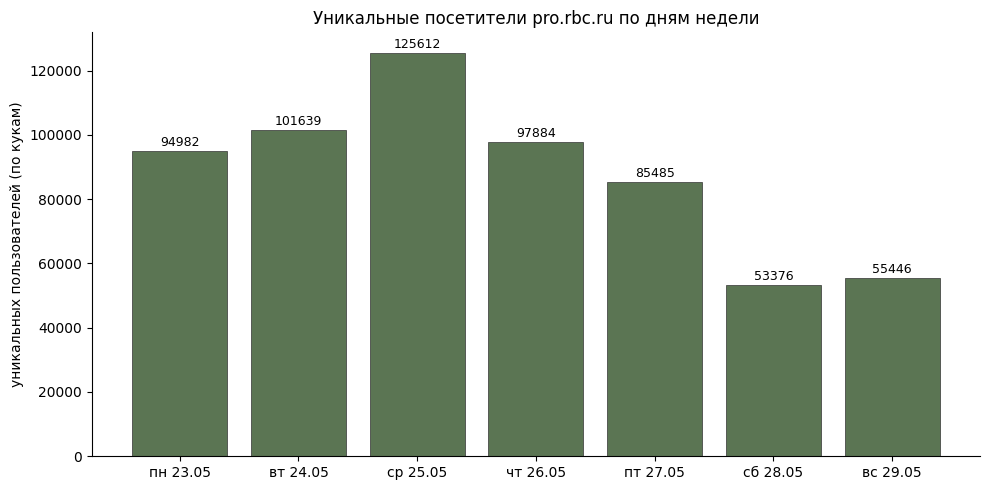

In [5]:
dates = list(FILES.keys())
labels = ['пн 23.05','вт 24.05','ср 25.05','чт 26.05','пт 27.05','сб 28.05','вс 29.05']
values = [daily_unique_splituid[d] for d in dates]

plt.figure(figsize=(10,5))
plt.bar(labels, values, color='#5b7553', edgecolor='#333333', linewidth=0.5)
plt.title('Уникальные посетители pro.rbc.ru по дням недели')
plt.ylabel('уникальных пользователей (по кукам)')
for i,v in enumerate(values):
    plt.text(i, v+1500, str(v), ha='center', fontsize=9)
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

501 545 уникальных пользователей за неделю, если считать по кукам. Пик — среда, 25 мая, 125 612 человек, и он заметно выбивается из ряда, почти на четверть выше соседних дней. Ниже это подтвердится и по авторизованным пользователям, так что дело, похоже, не в случайности.

## 4. Вопрос 2 — то же самое, но только залогиненные

In [6]:
print('Всего уникальных авторизованных пользователей (uuid) за неделю:', len(global_auth_uuid))
peak_day_auth = max(daily_unique_auth_uuid, key=daily_unique_auth_uuid.get)
print('День с пиком посещаемости авторизованных:', peak_day_auth, '->', daily_unique_auth_uuid[peak_day_auth])
daily_unique_auth_uuid

Всего уникальных авторизованных пользователей (uuid) за неделю: 33630
День с пиком посещаемости авторизованных: 2022-05-25 -> 13174


{'2022-05-23': 10935,
 '2022-05-24': 11517,
 '2022-05-25': 13174,
 '2022-05-26': 10323,
 '2022-05-27': 9742,
 '2022-05-28': 5558,
 '2022-05-29': 5917}

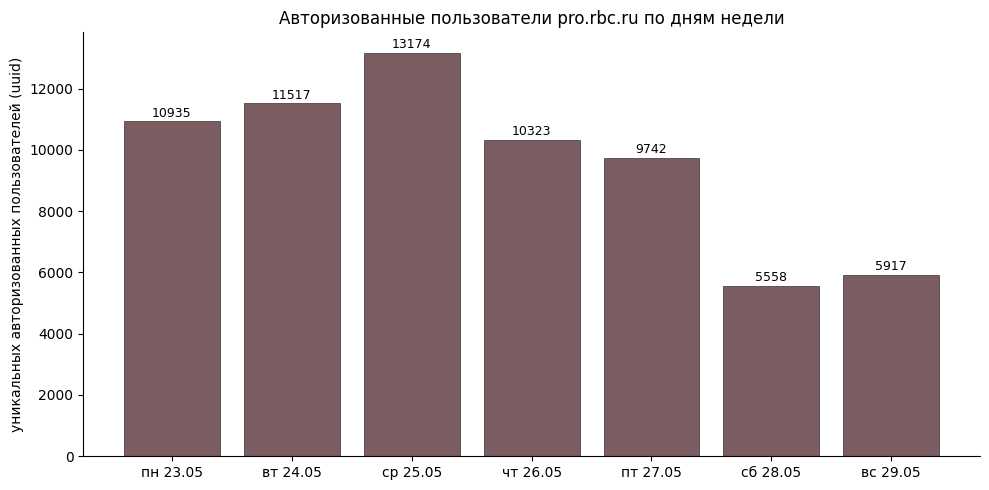

In [7]:
values_auth = [daily_unique_auth_uuid[d] for d in dates]
plt.figure(figsize=(10,5))
plt.bar(labels, values_auth, color='#7a5c61', edgecolor='#333333', linewidth=0.5)
plt.title('Авторизованные пользователи pro.rbc.ru по дням недели')
plt.ylabel('уникальных авторизованных пользователей (uuid)')
for i,v in enumerate(values_auth):
    plt.text(i, v+150, str(v), ha='center', fontsize=9)
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

33 630 уникальных авторизованных пользователей за неделю, пик снова в среду (13 174). Раз пик по залогиненным совпадает с пиком по всей аудитории, значит в среду был не разовый наплыв анонимного трафика откуда-то со стороны, а рост именно у постоянной, узнаваемой аудитории — скорее всего из-за конкретного заметного материала или новости в этот день.

## 5. Вопрос 3 — сколько браузеров у одного авторизованного пользователя

In [8]:
browser_counts = np.array([len(s) for s in uuid_to_splituid.values()])

print('Авторизованных пользователей:', len(browser_counts))
print('Среднее кол-во кук на пользователя:', browser_counts.mean().round(2))
print('Медиана:', np.median(browser_counts))
print('Пользователей с ровно 1 кукой:', (browser_counts == 1).sum(),
      f'({(browser_counts==1).mean()*100:.1f}%)')
print('Пользователей, использующих БОЛЕЕ 10 браузеров:', (browser_counts > 10).sum())

Авторизованных пользователей: 33630
Среднее кол-во кук на пользователя: 1.6
Медиана: 1.0
Пользователей с ровно 1 кукой: 28336 (84.3%)
Пользователей, использующих БОЛЕЕ 10 браузеров: 6


Шестеро с числом браузеров больше 10 — это мало, но стоит посмотреть на них поимённо, вдруг там что-то странное.

In [9]:
top = sorted(uuid_to_splituid.items(), key=lambda x: -len(x[1]))[:6]
for u, s in top:
    print(u, '->', len(s), 'кук')

7aa090d5-ef64-4573-997c-9a40a9e14a4c -> 13213 кук
bc30e8df-cdff-4f9a-a9bc-89fd5af2a9d4 -> 14 кук
368b2f02-a76f-4415-88c6-0a26f00e70b6 -> 12 кук
37c02d15-3f32-4f53-9ee1-e60c90451928 -> 11 кук
666042cf-644c-4d5f-8938-de8530039ca0 -> 11 кук
fc5156ce-3d02-43f3-8856-9ff45a236277 -> 11 кук


И действительно, что-то странное. Один uuid дал 13 213 кук, при том что следующий по счёту результат — всего 14. Разница на три порядка, живой человек так себя вести не может. Заглянул, какие запросы шли от этого id.

In [10]:
target = '7aa090d5-ef64-4573-997c-9a40a9e14a4c'
df = pd.read_csv(f'{DATA_DIR}/2022-05-23.csv', dtype=str)
sub = df[df['uuid'] == target]
print('Запросов от этого uuid только за понедельник:', len(sub))
print('Из них уникальных splituid только за этот день:', sub['splituid'].nunique())
sub['request_uri'].head(5).tolist()

Запросов от этого uuid только за понедельник: 2182
Из них уникальных splituid только за этот день: 1961


['/api/v1/user/pro/articles/getByTag/5d3ec8909a79477ca20dca0a?offset=0&limit=10',
 '/',
 '/',
 '/',
 '/api/v1/user/pro/articles/getByTag/5d3ec6da9a79477a55f9819b?offset=0&limit=10']

Почти все запросы этого uuid идут во внутренний API, и с очень высокой частотой на протяжении дня. Это не человек, а бот, скрипт мониторинга или какая-то серверная интеграция, которой присвоили обычный пользовательский токен. Такой id стоит исключать из подобной аналитики на постоянной основе — без него реальных «мультибраузерных» пользователей остаётся пятеро, с 11-14 устройствами каждый, что уже похоже на правду (рабочий компьютер, личный ноутбук, телефон, иногда режим инкогнито).

В сухом остатке: в среднем на одного авторизованного пользователя приходится 1,6 куки, медиана — 1, и 84% заходят всегда с одного браузера.

## 6. Вопрос 4 — когда авторизованные пользователи заходят чаще всего

In [11]:
weekday_idx = [0,1,2,3,4]   # Пн-Пт
weekend_idx = [5,6]         # Сб-Вс

weekday_sum = hourly_events_auth[weekday_idx].sum(axis=0)
weekend_sum = hourly_events_auth[weekend_idx].sum(axis=0)

weekday_avg = weekday_sum / len(weekday_idx)
weekend_avg = weekend_sum / len(weekend_idx)

print('Пик в будни: час', weekday_avg.argmax(), '-> среднее', round(weekday_avg.max(),1), 'запросов/день')
print('Пик в выходные: час', weekend_avg.argmax(), '-> среднее', round(weekend_avg.max(),1), 'запросов/день')

Пик в будни: час 9 -> среднее 20131.2 запросов/день
Пик в выходные: час 10 -> среднее 8629.0 запросов/день


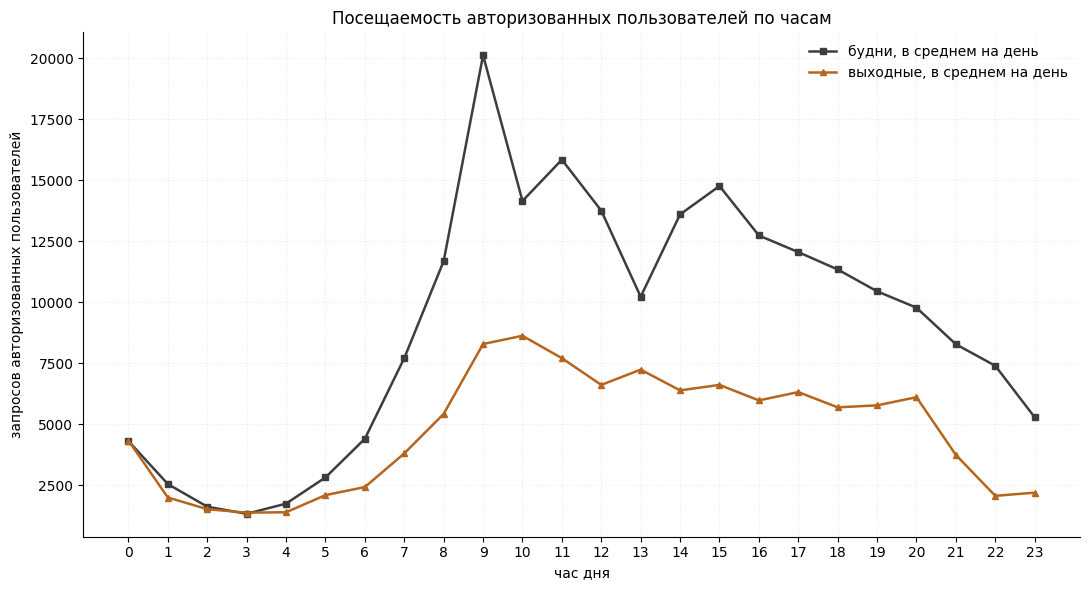

In [12]:
hours = list(range(24))
plt.figure(figsize=(11,6))
plt.plot(hours, weekday_avg, marker='s', markersize=5, linewidth=1.8, label='будни, в среднем на день', color='#3d3d3d')
plt.plot(hours, weekend_avg, marker='^', markersize=5, linewidth=1.8, label='выходные, в среднем на день', color='#b5651d')
plt.xlabel('час дня')
plt.ylabel('запросов авторизованных пользователей')
plt.title('Посещаемость авторизованных пользователей по часам')
plt.xticks(hours)
plt.grid(alpha=0.25, linestyle=':')
plt.legend(frameon=False)
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

Будни считаются по 5 дням, выходные по 2, поэтому сравниваю средние, а не суммы, иначе выходные заранее проиграли бы просто по количеству дней.

В будни виден чёткий рабочий профиль: рост с 7 до 9 утра, резкий пик ровно к девяти (люди пришли на работу и открыли новости), потом спад с двумя локальными всплесками около 11 и особенно к 15 часам — похоже на возврат к делам после обеда. В выходные никакого утреннего рывка нет, аудитория подтягивается на сайт постепенно, а пик сдвинут на час позже, к 10 утра. По абсолютному уровню выходные примерно в 2,3 раза тише пикового будничного часа — из всех четырёх вопросов это, пожалуй, самый однозначный результат: продукт используется прежде всего как рабочий инструмент, а не для чтения на досуге.

## 7. Коротко, что получилось

За неделю с 23 по 29 мая 2022 на pro.rbc.ru заходили 501 545 уникальных пользователей, из них 33 630 залогинены — около 6,7% от общего числа. Пик и по всей аудитории, и по залогиненным пришёлся на одну и ту же среду, 25 мая, что говорит скорее о содержательном инфоповоде в этот день, чем о случайном всплеске анонимного трафика. Подавляющее большинство залогиненных пользователей (84%) всегда заходят с одного браузера, а редкие случаи с аномально большим числом кук на аккаунт при ближайшем рассмотрении оказались ботом, а не активным человеком с десятком устройств. И наконец, трафик залогиненных пользователей чётко следует рабочему графику: пик в 9 утра в будни против более сглаженной картины и часового сдвига в выходные.
